# Homework 1 — MLP

Predict hourly energy use (`log1p(meter_reading)`, scored with RMSLE) with a small MLP, and compare it with LightGBM.
Data: [data_aggregation.ipynb](../preprocessing/data_aggregation.ipynb); choices follow [EDA.ipynb](../eda/EDA.ipynb).
Tools: PyTorch Lightning and MLflow ([Frameworks](#frameworks)).

Models are compared on 4 seasonal folds, like in every other notebook: a single Oct–Dec split tests only one season
([adversarial.ipynb](../validation/adversarial.ipynb)). Tuning follows in the notebooks listed under
[Follow-up](#follow-up).

In [1]:
import sys

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import DATA, FOLDS, KBTU_TO_KWH, METERS, PROCESSED
from ashrae.data import read_processed, split
from ashrae.features import add_series_mean, build_features
from ashrae.metrics import rmsle, rmsle_by_meter
from ashrae.modeling import MLP, MeterMLP, make_loaders, predict
from ashrae.plots import plot_curves
from ashrae.tracking import Experiment

EPOCHS = 10
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold, as in the other notebooks
experiment = Experiment("ashrae-mlp")

MLflow: sqlite:////Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/mlflow.db, experiment 'ashrae-mlp', session 2026-09-27 16:14:12


## Data

- 4 folds: each validates on one 3-month block of 2016 and trains on the other nine. 2M training and 500K validation
  rows are sampled per fold.
- Anomalies are dropped from training only ([EDA §9](../eda/EDA.ipynb#broken)). Validation is scored on every row, as
  Kaggle scores, and also on clean rows (without anomalies), the error on real consumption
  ([season_validation.ipynb](../validation/season_validation.ipynb)).
- Models are compared by the fold average on all rows.
- Target `log1p(meter_reading)`, so MSE loss is exactly RMSLE.

In [2]:
df = read_processed()
n_buildings = int(df.building_id.max()) + 1


def fold_data(val_months):
    """Features and loaders of one fold, with and without the series mean, plus what's needed to score it."""
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    X_train, X_val = build_features(train_df, year_median), build_features(val_df, year_median)
    X_train_sm, X_val_sm = add_series_mean(X_train, train_df, train_df), add_series_mean(X_val, val_df, train_df)
    return {
        "X": (X_train, X_val),
        "loaders": make_loaders(train_df, val_df, X_train, X_val)[:2],
        "loaders_sm": make_loaders(train_df, val_df, X_train_sm, X_val_sm)[:2],
        "y_train": np.log1p(train_df.meter_reading.to_numpy(dtype="float32")),
        "y_val": np.log1p(val_df.meter_reading.to_numpy(dtype="float32")),
        "meter": val_df.meter.to_numpy(),
        "anomaly": val_df.anomaly.to_numpy(),
    }


folds = {name: fold_data(months) for name, months in FOLDS.items()}
del df

## Features

- `meter`, `primary_use`: one-hot. `log1p(square_feet)`. `year_built`: training median plus a missing flag.
- Weather as given (already in local time); wind direction as sin/cos.
- Hour and day of week as sin/cos, from `local_timestamp`.
- For one model, the series mean: mean `log1p` reading of each building × meter series on the training rows.

Code: [ashrae/features.py](../ashrae/features.py).

In [3]:
n_features = folds["Jan–Mar"]["X"][0].shape[1]
print(f"{n_features} features: {', '.join(folds['Jan–Mar']['X'][0].columns)}")

33 features: log_square_feet, year_built_missing, year_built, air_temperature, dew_temperature, sea_level_pressure, wind_speed, wind_dir_sin, wind_dir_cos, hour_sin, hour_cos, dow_sin, dow_cos, meter_0, meter_1, meter_2, meter_3, use_Education, use_Entertainment/public assembly, use_Food sales and service, use_Healthcare, use_Lodging/residential, use_Manufacturing/industrial, use_Office, use_Other, use_Parking, use_Public services, use_Religious worship, use_Retail, use_Services, use_Technology/science, use_Utility, use_Warehouse/storage


## Models

All: 2 hidden layers of 64 units, ReLU, Adam (lr 1e-3), batch 4096, 10 epochs.

| Model | Change |
| --- | --- |
| mlp | one output |
| mlp_bn | + BatchNorm after each hidden layer |
| mlp_4out | + one output per meter type (heating and cooling react to weather in opposite directions); each row uses its own meter's output |
| mlp_4out_mean | + the series mean as an input, which tells the model which building it is |
| mlp_4out_emb | + a learned 16-number vector per building (an embedding) instead |
| lgbm | LightGBM on the same features, untuned (500 trees, learning rate 0.1, 63 leaves) |

One more run checks an initialization: **mlp_4out_emb_he** is mlp_4out_emb with He initialization instead of PyTorch's
default.

Code: `MLP` and `MeterMLP` in [ashrae/modeling.py](../ashrae/modeling.py).

## Training

One `EnergyModel` trains every network ([ashrae/modeling.py](../ashrae/modeling.py)). `Experiment.fit`
([ashrae/tracking.py](../ashrae/tracking.py)) logs settings, per-epoch RMSLE and per-meter RMSLE to MLflow, tagged
with fold and model. 24 network runs (6 × 4 folds), then LightGBM on each fold.

In [4]:
def he_init(net):
    """He (Kaiming) initialization of every linear layer, suited to ReLU; biases start at 0."""
    for layer in net.modules():
        if isinstance(layer, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            torch.nn.init.zeros_(layer.bias)
    return net


NETS = {  # name: (network, whether it gets the series mean as an input)
    "mlp": (lambda: MLP(n_features), False),
    "mlp_bn": (lambda: MLP(n_features, batch_norm=True), False),
    "mlp_4out": (lambda: MeterMLP(n_features), False),
    "mlp_4out_mean": (lambda: MeterMLP(n_features + 1), True),
    "mlp_4out_emb": (lambda: MeterMLP(n_features, n_buildings), False),
    "mlp_4out_emb_he": (lambda: he_init(MeterMLP(n_features, n_buildings)), False),
}


def scores(y, pred, meter, anomaly):
    """Validation RMSLE on all rows (overall and per meter) and on clean rows."""
    return {**rmsle_by_meter(y, pred, meter), "val_rmsle_clean": rmsle(y[~anomaly], pred[~anomaly])}


results = []
for fold, data in folds.items():
    for name, (make_net, series_mean) in NETS.items():
        train_loader, val_loader = data["loaders_sm" if series_mean else "loaders"]
        model, run_id = experiment.fit(make_net, train_loader, val_loader, run_name=f"{name} | {fold}",
                                       epochs=EPOCHS, tags={"fold": fold, "model": name})
        s = scores(data["y_val"], predict(model, val_loader), data["meter"], data["anomaly"])
        # the overall per-epoch value is already logged by Lightning
        experiment.log_metrics(run_id, {k: v for k, v in s.items() if k != "val_rmsle"})
        results.append({"fold": fold, "model": name, "train_rmsle": experiment.history(run_id, "train_rmsle")[-1], **s})
        print(f"{fold} {name:16s} val RMSLE {s['val_rmsle']:.4f} (clean rows {s['val_rmsle_clean']:.4f})")

Jan–Mar mlp              val RMSLE 1.7192 (clean rows 1.3692)


Jan–Mar mlp_bn           val RMSLE 1.6946 (clean rows 1.3546)


Jan–Mar mlp_4out         val RMSLE 1.6855 (clean rows 1.3308)


Jan–Mar mlp_4out_mean    val RMSLE 1.4570 (clean rows 0.9819)


Jan–Mar mlp_4out_emb     val RMSLE 1.4206 (clean rows 0.9351)


...

Oct–Dec mlp_bn           val RMSLE 1.4189 (clean rows 1.3568)


Oct–Dec mlp_4out         val RMSLE 1.3993 (clean rows 1.3340)


Oct–Dec mlp_4out_mean    val RMSLE 1.1141 (clean rows 1.0265)


Oct–Dec mlp_4out_emb     val RMSLE 1.1089 (clean rows 1.0201)


Oct–Dec mlp_4out_emb_he  val RMSLE 1.1079 (clean rows 1.0173)


In [5]:
# Imported only here: loading LightGBM before torch crashes the kernel on macOS (both ship an OpenMP runtime).
import lightgbm as lgb

params = {"n_estimators": 500, "learning_rate": 0.1, "num_leaves": 63}
for fold, data in folds.items():
    X_train, X_val = data["X"]
    # n_jobs=1: multi-threaded LightGBM also segfaults once torch has loaded its OpenMP runtime
    lgbm = lgb.LGBMRegressor(**params, random_state=0, verbose=-1, n_jobs=1).fit(X_train, data["y_train"])
    s = scores(data["y_val"], lgbm.predict(X_val), data["meter"], data["anomaly"])
    with mlflow.start_run(run_name=f"lgbm | {fold}",
                          tags={"session": experiment.session, "fold": fold, "model": "lgbm"}):
        mlflow.log_params(params)
        mlflow.log_metrics(s)
    results.append({"fold": fold, "model": "lgbm", **s})
    print(f"{fold} {'lgbm':16s} val RMSLE {s['val_rmsle']:.4f} (clean rows {s['val_rmsle_clean']:.4f})")

results = pd.DataFrame(results)

Jan–Mar lgbm             val RMSLE 1.4866 (clean rows 1.0487)


Apr–Jun lgbm             val RMSLE 1.2971 (clean rows 1.0051)


Jul–Sep lgbm             val RMSLE 1.1723 (clean rows 1.0498)


Oct–Dec lgbm             val RMSLE 1.1641 (clean rows 1.0778)


## Results

Validation RMSLE per fold on all rows, the fold average, and the fold averages on clean rows and on training rows.

fold,Jan–Mar,Apr–Jun,Jul–Sep,Oct–Dec,average,"average, clean rows",training
"RMSLE, all rows unless noted",,,,,,,
mlp,1.719,1.593,1.497,1.427,1.559,1.380,1.345
mlp_bn,1.695,1.582,1.487,1.419,1.546,1.368,1.323
mlp_4out,1.685,1.584,1.467,1.399,1.534,1.350,1.305
mlp_4out_mean,1.457,1.257,1.147,1.114,1.244,0.994,0.885
mlp_4out_emb,1.421,1.222,1.047,1.109,1.200,0.937,0.827
mlp_4out_emb_he,1.422,1.221,1.045,1.108,1.199,0.933,0.822
lgbm,1.487,1.297,1.172,1.164,1.280,1.045,NaN


,electricity,chilledwater,steam,hotwater
"fold average, all rows",,,,
mlp,1.163,1.899,2.121,2.009
mlp_bn,1.149,1.878,2.119,1.994
mlp_4out,1.153,1.856,2.091,1.949
mlp_4out_mean,0.957,1.476,1.616,1.627
mlp_4out_emb,0.950,1.396,1.532,1.566
mlp_4out_emb_he,0.954,1.386,1.523,1.567
lgbm,1.019,1.501,1.647,1.625


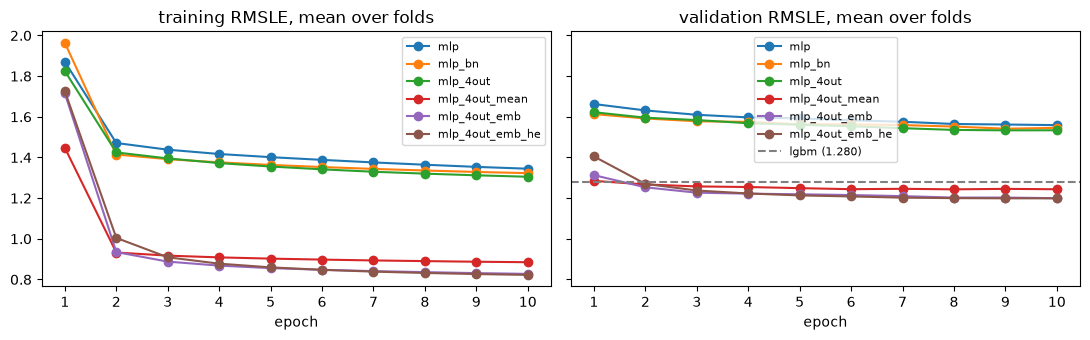

In [6]:
order = [*NETS, "lgbm"]
table = results.pivot(index="model", columns="fold", values="val_rmsle").loc[order, list(FOLDS)]
averages = results.groupby("model")[["val_rmsle", "val_rmsle_clean", "train_rmsle"]].mean()
table["average"] = averages.val_rmsle
table["average, clean rows"] = averages.val_rmsle_clean
table["training"] = averages.train_rmsle
display(table.round(3).rename_axis("RMSLE, all rows unless noted"))

meters = results.groupby("model")[[f"val_rmsle_{name}" for name in METERS.values()]].mean().loc[order]
display(meters.rename(columns=lambda c: c.removeprefix("val_rmsle_")).round(3).rename_axis("fold average, all rows"))

runs = experiment.runs()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, key, title in zip(axes, ["train_rmsle", "val_rmsle"], ["training RMSLE", "validation RMSLE"]):
    curves = {name: np.mean([experiment.history(run_id, key) for run_id in runs[runs["tags.model"] == name].run_id],
                            axis=0).tolist() for name in NETS}
    plot_curves(ax, curves, f"{title}, mean over folds")
# LightGBM has no epochs: its fold-average validation score as a reference line
axes[1].axhline(averages.val_rmsle["lgbm"], color="gray", ls="--", label=f"lgbm ({averages.val_rmsle['lgbm']:.3f})")
axes[1].legend(fontsize=8)
plt.tight_layout()

## Findings

Fold averages on all rows unless noted.

- **Knowing the building matters most:** 1.534 → 1.244 with the series mean and 1.200 with an embedding. Both beat
  LightGBM (1.280) in every fold. Buildings with the same size, use and weather differ by orders of
  magnitude.
- **Embedding beats the series mean in every fold** (0.938 vs 0.994 on clean rows). The gap is smallest on Oct–Dec
  (1.110 vs 1.114), which is why they looked tied when this notebook compared on that split alone. Where the gain
  comes from: [mean_vs_embedding.ipynb](../validation/mean_vs_embedding.ipynb). mlp_4out_emb is the submitted model.
- **Architecture tweaks help a little:** BatchNorm 1.559 → 1.546 (every fold), one output per meter → 1.534 (3 of 4
  folds). Separate outputs help chilled water, steam and hot water, not electricity.
- **Hot water is hardest:** 1.57 for the best model, against 0.95 for electricity: fewest rows, most zeros.
- **Training 0.83 vs validation 1.20 is not overfitting.** On clean rows validation is 0.94: most of the gap is anomaly
  rows in validation ([season_validation.ipynb](../validation/season_validation.ipynb)); regularization doesn't help
  ([regularization_test.ipynb](regularization_test.ipynb)).
- **Data cleaning:** the anomaly rules improve LightGBM on clean rows but not on all rows, where the effect depends on
  the season ([EDA §9](../eda/EDA.ipynb#broken)).

One seed; differences below ~0.01 may be noise.

## What didn't work

- **He initialization:** same score as PyTorch's default (1.199 vs 1.200, embedding model). BatchNorm re-normalizes
  every hidden layer, so the starting weight scale barely matters in a 2-layer network.

<a id='follow-up'></a>

## Follow-up

Every notebook uses the same 4 folds.

| Question | Answer | Notebook |
| --- | --- | --- |
| Does a single Oct–Dec split represent the test set? | No, it tests one season: use 4 seasonal folds | [adversarial.ipynb](../validation/adversarial.ipynb) |
| Does regularization help? | No | [regularization_test.ipynb](regularization_test.ipynb) |
| Which optimizer? | Adam, best in every fold | [optimizers_test.ipynb](optimizers_test.ipynb) |
| Why is validation so much worse than training? | Mostly anomaly rows in validation | [season_validation.ipynb](../validation/season_validation.ipynb) |
| Series mean or embedding? | Embedding, by 0.047 on clean rows | [mean_vs_embedding.ipynb](../validation/mean_vs_embedding.ipynb) |
| How many epochs? | 20 (still improving slowly) | [epochs_test.ipynb](epochs_test.ipynb) |

<a id='test-predictions'></a>

## Test predictions

Final model: mlp_4out_emb retrained on all of 2016 (4M rows, anomalies dropped) for 20 epochs
([epochs_test.ipynb](epochs_test.ipynb)), as [adversarial.ipynb](../validation/adversarial.ipynb) step 4 says. It
predicts the 41.7M test rows in chunks. Predictions go back from `log1p`, and site 0 electricity back to kBTU, the unit
Kaggle scores it in.

In [7]:
FINAL_EPOCHS = 20  # epochs_test.ipynb: best fold-average epoch
full_df = read_processed()
final_df = full_df[~full_df.anomaly].sample(4_000_000, random_state=0)  # all of 2016
del full_df
final_median = final_df.year_built.median()
X_final = build_features(final_df, final_median)
final_loader, _, scaler = make_loaders(final_df, None, X_final, None)
model, _ = experiment.fit(lambda: MeterMLP(n_features, n_buildings), final_loader,
                          run_name="mlp_4out_emb | all 2016", epochs=FINAL_EPOCHS)
model = model.eval()
test_df = read_processed("test_merged.parquet")


@torch.no_grad()
def predict_chunk(chunk):
    x = scaler.transform(build_features(chunk, final_median).reindex(columns=X_final.columns, fill_value=0))
    batch = {
        "x": torch.tensor(x, dtype=torch.float32, device=model.device),
        "meter": torch.tensor(chunk.meter.to_numpy(), dtype=torch.long, device=model.device),
        "building": torch.tensor(chunk.building_id.to_numpy(), dtype=torch.long, device=model.device),
    }
    return model(batch).clamp(min=0).cpu().numpy()


pred_log = np.concatenate([predict_chunk(test_df.iloc[i : i + 1_000_000]) for i in range(0, len(test_df), 1_000_000)])
reading = np.expm1(pred_log)
reading[((test_df.site_id == 0) & (test_df.meter == 0)).to_numpy()] /= KBTU_TO_KWH

submission = pd.DataFrame({"row_id": test_df.row_id.to_numpy(), "meter_reading": reading}).sort_values("row_id")
sample_ids = pd.read_csv(DATA / "sample_submission.csv", usecols=["row_id"]).row_id
assert np.array_equal(submission.row_id, sample_ids) and np.isfinite(submission.meter_reading).all()
submission.to_csv(PROCESSED / "submission_mlp.csv", index=False, float_format="%.4f")
print(f"saved {PROCESSED / 'submission_mlp.csv'}: {len(submission):,} rows")

/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


saved /Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/data/processed/submission_mlp.csv: 41,697,600 rows


<a id='frameworks'></a>

## Frameworks

**PyTorch Lightning** organises the training ([Frameworks_guide.md](../../../Development%20Guide/Frameworks_guide.md)); the code is in [ashrae/modeling.py](../ashrae/modeling.py):

- `EnergyDataset` keeps all rows as tensors in memory. Its `__getitems__` returns a whole batch in one indexing step,
  so the DataLoader can shuffle and batch 3M rows without fetching them one at a time.
- `EnergyModel` (a `LightningModule`) holds the loss, the optimizer and the RMSLE metrics. Every network takes the
  same inputs `(x, meter, building)`, so one module trains all of them.
- A `Trainer` per model runs the loop on the Mac GPU (MPS) when available. Adding early stopping or checkpoints is a
  one-line callback.

**MLflow** records every run: its settings, per-epoch RMSLE, and per-meter scores. It's free and runs locally:
everything is stored in `mlflow.db` in the homework folder, and nothing leaves the machine. To browse all runs, start
the local web viewer from the `Homework 1` folder and open http://127.0.0.1:5000:

```
poetry run mlflow ui --backend-store-uri sqlite:///mlflow.db
```